# Mutual Fund Performance Analytics

**Bluestock Fintech Capstone**

This notebook evaluates mutual fund performance using financial metrics including daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, and a composite Fund Scorecard.

In [114]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress


plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [115]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

In [116]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [117]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


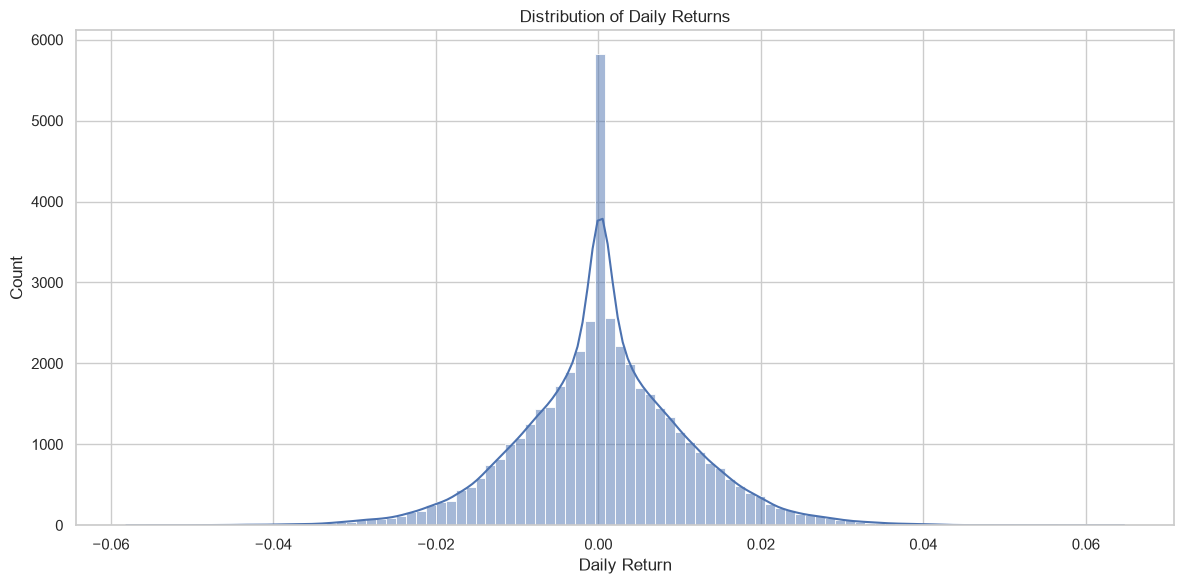

In [118]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.tight_layout()

plt.show()

## Daily Return Distribution

Daily returns are concentrated around zero with relatively few extreme values, which is consistent with the expected behavior of mutual fund NAV movements. The distribution appears approximately bell-shaped with mild tails caused by periods of higher market volatility.

## CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualized return of each mutual fund over different investment horizons. It provides a standardized metric for comparing long-term fund performance.

In [119]:
# Create CAGR function
def calculate_cagr(nav_data, years):
    records = []

    latest_date = nav_data["date"].max()
    start_date = latest_date - pd.DateOffset(years=years)

    for code in nav_data["amfi_code"].unique():

        df = nav_data[nav_data["amfi_code"] == code].sort_values("date")

        df_period = df[df["date"] >= start_date]

        if len(df_period) < 2:
            continue

        nav_start = df_period.iloc[0]["nav"]
        nav_end = df_period.iloc[-1]["nav"]

        cagr = ((nav_end / nav_start) ** (1 / years)) - 1

        records.append({
            "amfi_code": code,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(records)

In [120]:
cagr1 = calculate_cagr(nav, 1)
cagr3 = calculate_cagr(nav, 3)
cagr5 = calculate_cagr(nav, 5)

In [121]:
cagr = (
    cagr1
    .merge(cagr3, on="amfi_code", how="outer")
    .merge(cagr5, on="amfi_code", how="outer")
)

cagr = cagr.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [122]:
cagr.sort_values(
    "CAGR_5Y",
    ascending=False
).head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth
21,119598,0.827761,0.266699,0.280332,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.651387,0.270004,0.279174,DSP Small Cap Fund - Regular - Growth
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,0.214812,0.268700,0.256118,DSP Midcap Fund - Regular - Growth
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth


In [123]:
cagr.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

## Sharpe Ratio

The Sharpe Ratio evaluates risk-adjusted returns by comparing excess return over the risk-free rate against portfolio volatility. Higher values indicate better risk-adjusted performance.

In [124]:
RISK_FREE_RATE = 0.065

daily_rf = RISK_FREE_RATE / 252

sharpe_results = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (
        (mean_return - daily_rf)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

sharpe = pd.DataFrame(sharpe_results)

sharpe.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [125]:
sharpe = sharpe.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


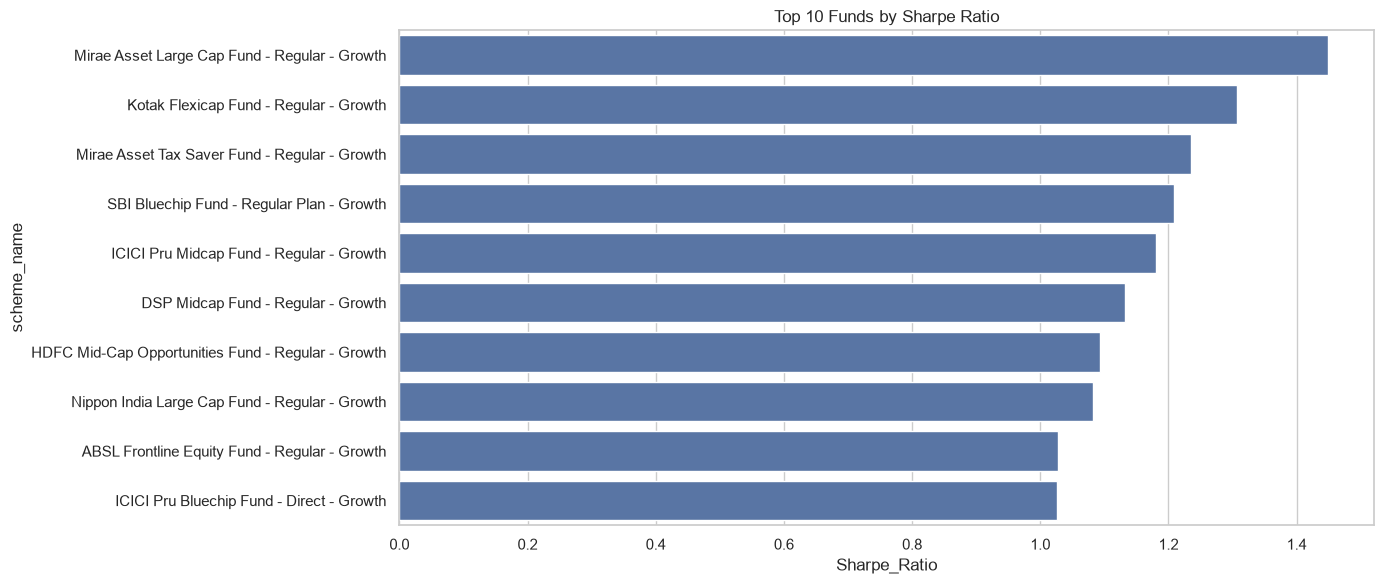

In [126]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=sharpe.head(10),
    x="Sharpe_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio_top10.png",
    dpi=300
)

plt.show()

In [127]:
sharpe.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

### Insight 3

Funds with higher Sharpe Ratios generated stronger returns for each unit of risk taken, indicating superior risk-adjusted performance compared with lower-ranked schemes.

## Sortino Ratio

The Sortino Ratio improves upon the Sharpe Ratio by considering only downside volatility. It measures return relative to harmful risk rather than total volatility.

In [128]:
RISK_FREE_RATE = 0.065
daily_rf = RISK_FREE_RATE / 252

sortino_results = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    mean_return = returns.mean()

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })

sortino = pd.DataFrame(sortino_results)

sortino = sortino.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino = sortino.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino.head(10)

,amfi_code,Sortino_Ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


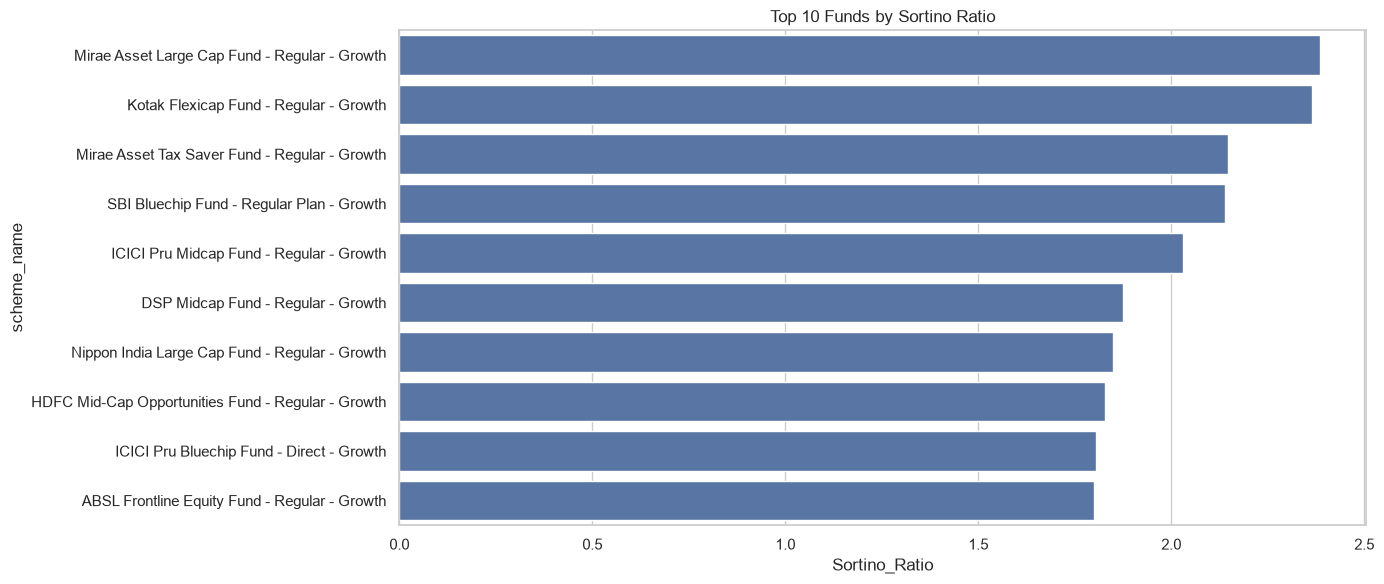

In [129]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=sortino.head(10),
    x="Sortino_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio_top10.png",
    dpi=300
)

plt.show()

In [130]:
sortino.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [131]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.columns.tolist()
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


## Alpha and Beta Analysis

Alpha measures the excess return generated by a fund relative to the benchmark after adjusting for market risk. Beta measures the sensitivity of a fund's returns to movements in the benchmark index.

This analysis uses daily returns and Ordinary Least Squares (OLS) regression against the NIFTY 100 index.

In [132]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Keep only NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Daily returns
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [133]:
from scipy.stats import linregress

alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]].copy()

    merged = fund.merge(
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": intercept * 252,
        "Beta": slope,
        "R_Squared": r_value**2
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [134]:
alpha_beta = alpha_beta.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta = alpha_beta[
    [
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta",
        "R_Squared"
    ]
]

alpha_beta.head()

,amfi_code,scheme_name,Alpha,Beta,R_Squared
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268,0.002665
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158,0.000015
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,0.000012
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,0.000348
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,0.001064


In [135]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

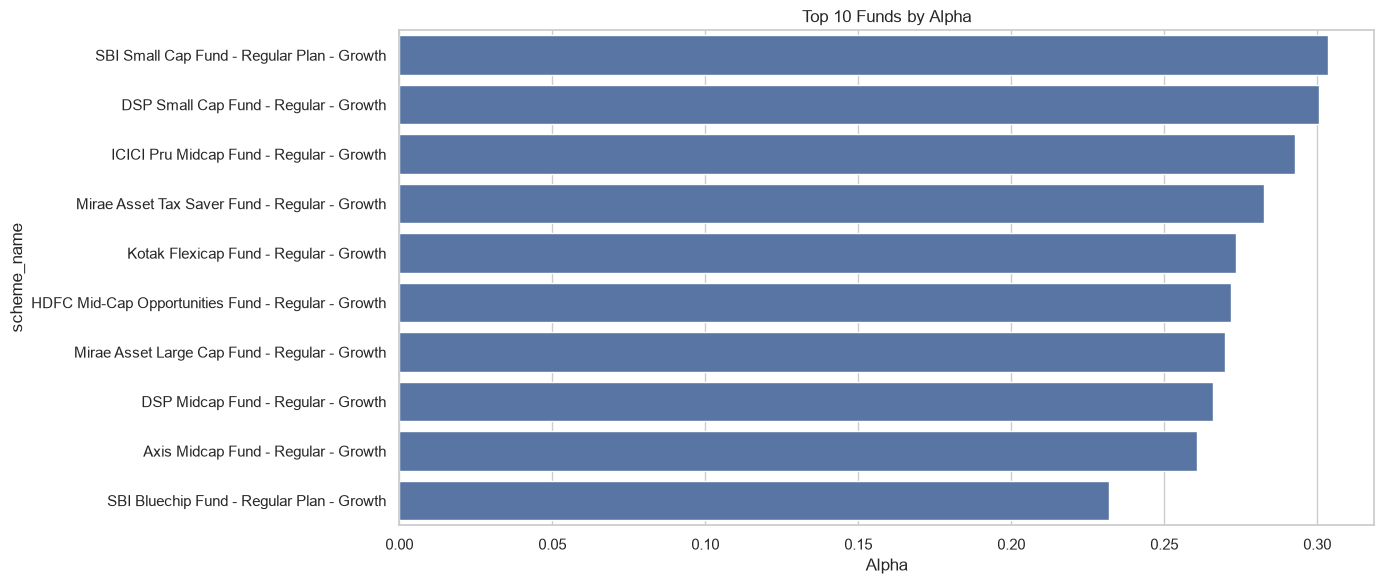

In [136]:
top_alpha = alpha_beta.sort_values(
    "Alpha",
    ascending=False
).head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_alpha,
    x="Alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.savefig(
    "../reports/top_alpha.png",
    dpi=300
)

plt.show()

### Insight 4

Funds with positive Alpha consistently outperformed the NIFTY 100 benchmark after adjusting for market risk. Beta values close to 1 indicate market-like behavior, while lower values suggest more defensive investment characteristics.

## Maximum Drawdown

Maximum Drawdown measures the largest decline from a fund's historical peak NAV. It is an important downside risk metric used to evaluate capital preservation.

In [137]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df.sort_values("date")

    # Running maximum NAV
    df["running_max"] = df["nav"].cummax()

    # Drawdown
    df["drawdown"] = (
        df["nav"] /
        df["running_max"]
    ) - 1

    # Worst drawdown
    trough_idx = df["drawdown"].idxmin()

    trough_row = df.loc[trough_idx]

    # Peak before trough
    peak_df = df.loc[:trough_idx]

    peak_idx = peak_df["nav"].idxmax()

    peak_row = df.loc[peak_idx]

    # Recovery (first NAV >= previous peak)
    recovery = df.loc[
        trough_idx:
    ]

    recovered = recovery[
        recovery["nav"] >= peak_row["nav"]
    ]

    if len(recovered) > 0:
        recovery_date = recovered.iloc[0]["date"]
    else:
        recovery_date = pd.NaT

    drawdown_results.append({

        "amfi_code": code,

        "Max_Drawdown": trough_row["drawdown"],

        "Peak_Date": peak_row["date"],

        "Trough_Date": trough_row["date"],

        "Recovery_Date": recovery_date

    })

drawdown = pd.DataFrame(drawdown_results)

drawdown = drawdown.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

drawdown.head()

,amfi_code,Max_Drawdown,Peak_Date,Trough_Date,Recovery_Date,scheme_name
0,100016,-0.247344,2022-03-30,2022-09-15,2023-03-14,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-05-23,2023-07-28,2024-01-30,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-03-11,2022-05-12,2022-07-27,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-04-24,2023-07-05,2023-09-28,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2024-11-21,2026-05-11,NaT,ABSL Small Cap Fund - Regular - Growth


In [138]:
drawdown.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

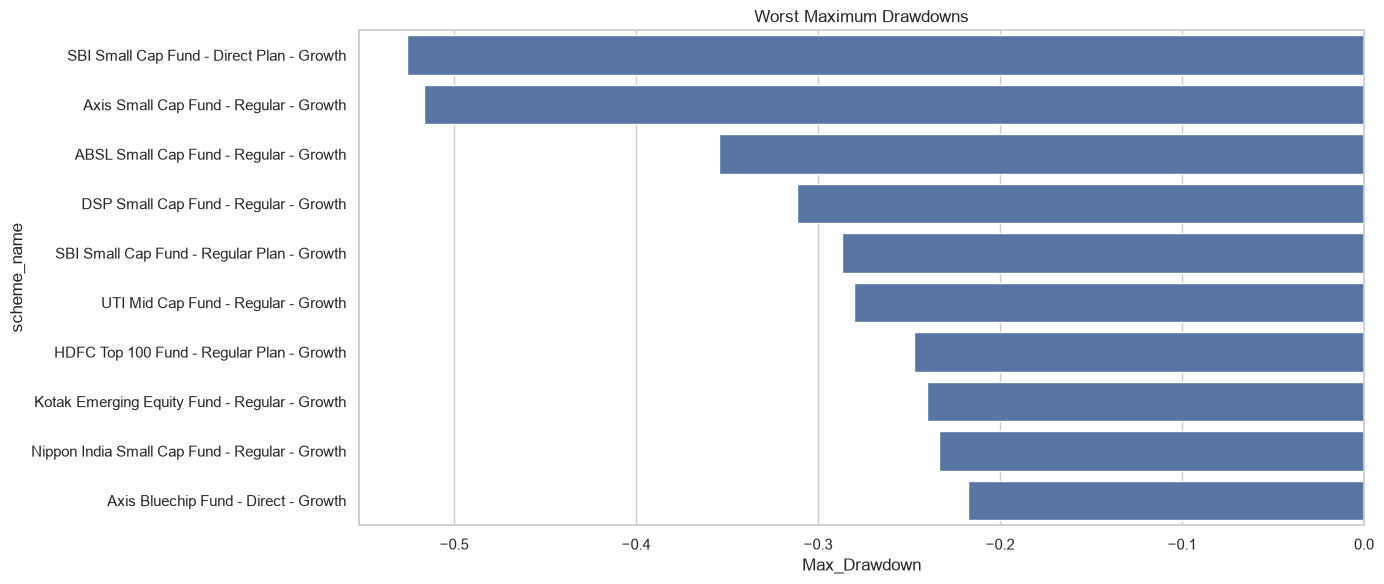

In [139]:
worst10 = drawdown.sort_values(
    "Max_Drawdown"
).head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    data=worst10,
    x="Max_Drawdown",
    y="scheme_name"
)

plt.title("Worst Maximum Drawdowns")

plt.tight_layout()

plt.savefig(
    "../reports/max_drawdown.png",
    dpi=300
)

plt.show()

## Composite Fund Scorecard

The Fund Scorecard combines multiple performance metrics into a single score using weighted ranking:

- 30% → 3-Year CAGR
- 25% → Sharpe Ratio
- 20% → Alpha
- 15% → Expense Ratio (inverse)
- 10% → Maximum Drawdown (inverse)

In [140]:
from sklearn.preprocessing import MinMaxScaler

scorecard = (
    cagr.merge(sharpe, on=["amfi_code", "scheme_name"])
        .merge(alpha_beta, on=["amfi_code", "scheme_name"])
        .merge(drawdown, on=["amfi_code", "scheme_name"])
        .merge(
            performance[
                ["amfi_code", "expense_ratio_pct"]
            ],
            on="amfi_code"
        )
)

# Features for scoring
features = scorecard[
    [
        "CAGR_3Y",
        "Sharpe_Ratio",
        "Alpha",
        "expense_ratio_pct",
        "Max_Drawdown"
    ]
].copy()

# Invert metrics where LOWER is better
features["expense_ratio_pct"] = -features["expense_ratio_pct"]
features["Max_Drawdown"] = -features["Max_Drawdown"]

# Normalize to 0–100
scaler = MinMaxScaler(feature_range=(0,100))

scaled = scaler.fit_transform(features)

scaled = pd.DataFrame(
    scaled,
    columns=[
        "ReturnScore",
        "SharpeScore",
        "AlphaScore",
        "ExpenseScore",
        "DrawdownScore"
    ]
)

scorecard = pd.concat(
    [scorecard.reset_index(drop=True), scaled],
    axis=1
)

In [141]:
scorecard["ReturnRank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["SharpeRank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["AlphaRank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["ExpenseRank"] = scorecard["expense_ratio_pct"].rank()

scorecard["DrawdownRank"] = scorecard["Max_Drawdown"].rank(ascending=False)

In [142]:
scorecard["FundScore"] = (

30*scorecard["ReturnRank"]/40 +

25*scorecard["SharpeRank"]/40 +

20*scorecard["AlphaRank"]/40 +

15*scorecard["ExpenseRank"]/40 +

10*scorecard["DrawdownRank"]/40

)

scorecard["FundScore"] = (
    100 -
    scorecard["FundScore"]
)

scorecard = scorecard.sort_values(
    "FundScore",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,Sharpe_Ratio,Alpha,Beta,R_Squared,Max_Drawdown,...,SharpeScore,AlphaScore,ExpenseScore,DrawdownScore,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,FundScore
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,0.269838,0.023684,4.625437e-04,-0.112657,...,100.000000,87.779844,16.513761,21.281907,2.0,1.0,7.0,23.0,8.0,83.7500
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth,1.180101,0.292636,0.000549,1.345534e-07,-0.181885,...,88.153413,96.088262,25.688073,34.474071,5.0,5.0,3.0,15.0,25.0,79.7500
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth,1.306744,0.273305,-0.022830,3.430543e-04,-0.129740,...,93.747524,89.043376,17.431193,24.537153,7.0,2.0,5.0,22.0,13.0,79.5000
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,0.005104,1.206652e-05,-0.162172,...,84.336812,88.550991,23.853211,30.717522,4.0,7.0,6.0,17.0,20.0,78.2500
24,120504,0.130643,0.324874,0.202340,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,0.211948,0.016232,2.121613e-04,-0.125883,...,81.369557,66.683200,77.064220,23.802172,3.0,10.0,13.0,12.0,12.0,77.5000
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth,0.998231,0.260767,-0.066265,1.936879e-03,-0.209609,...,80.119774,84.474153,23.853211,39.757142,1.0,11.0,9.0,17.0,28.0,74.5000
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth,1.208267,0.232010,-0.031751,8.869789e-04,-0.150124,...,89.397544,73.994346,9.174312,28.421593,6.0,4.0,10.0,30.5,17.0,72.3125
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,0.282704,0.018134,1.748889e-04,-0.163967,...,90.575332,92.468675,3.669725,31.059645,8.0,3.0,4.0,36.5,21.0,71.1875
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,1.027213,0.213998,0.021086,3.480482e-04,-0.112916,...,81.399993,67.430130,3.669725,21.331200,9.0,9.0,12.0,36.5,9.0,65.6875
21,119598,0.827761,0.266699,0.280332,SBI Small Cap Fund - Regular Plan - Growth,0.945308,0.303370,-0.023196,1.414258e-04,-0.287060,...,77.782052,100.000000,19.266055,54.516364,12.0,14.0,1.0,21.0,36.0,64.8750


In [143]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

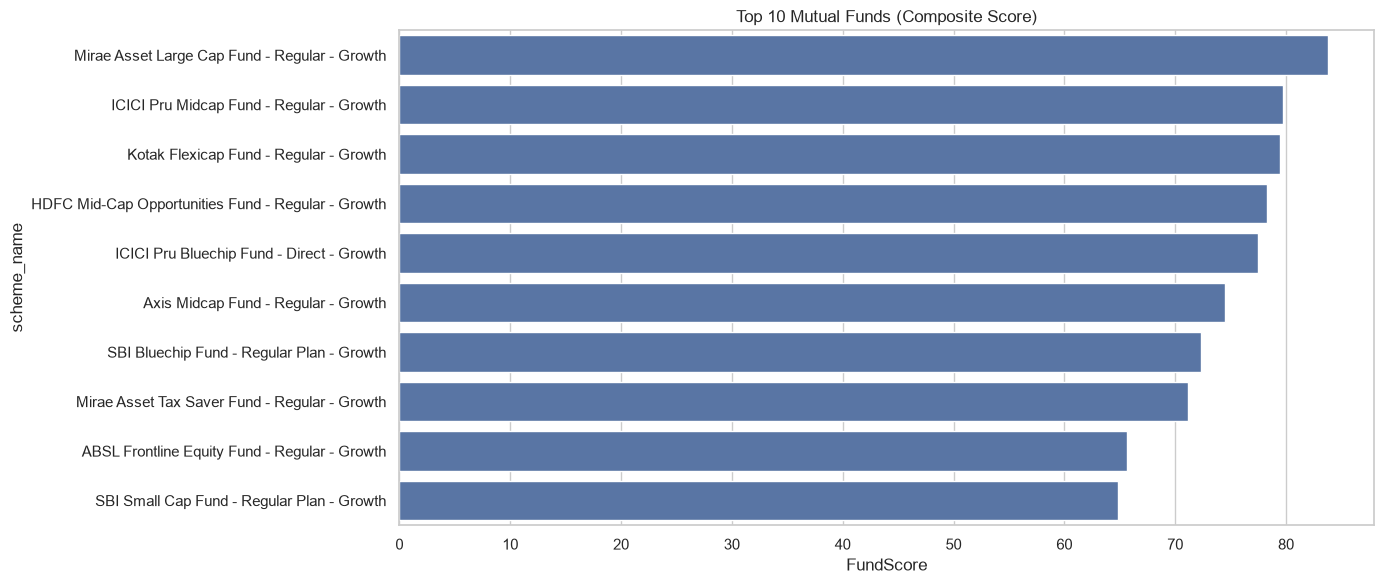

In [144]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=scorecard.head(10),
    x="FundScore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds (Composite Score)")

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard.png",
    dpi=300
)

plt.show()

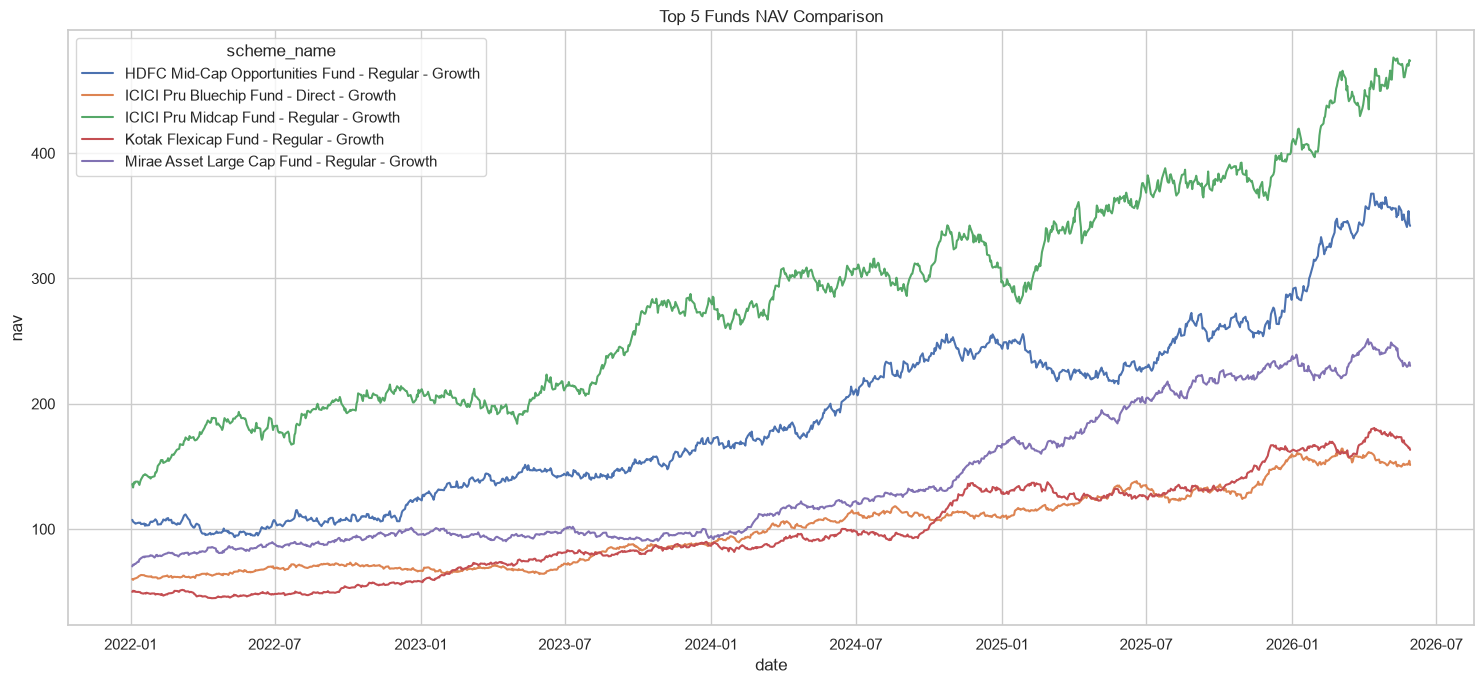

In [145]:
top5 = scorecard.head(5)["amfi_code"]

comparison = nav[
    nav["amfi_code"].isin(top5)
].merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

plt.figure(figsize=(15,7))

sns.lineplot(
    data=comparison,
    x="date",
    y="nav",
    hue="scheme_name"
)

plt.title("Top 5 Funds NAV Comparison")

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [146]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

end_date = benchmark["date"].max()
start_date = end_date - pd.DateOffset(years=3)

benchmark = benchmark[
    benchmark["date"] >= start_date
]

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Daily Returns
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

# Normalized Values
nifty50["Normalized"] = (
    nifty50["close_value"] /
    nifty50.iloc[0]["close_value"]
) * 100

nifty100["Normalized"] = (
    nifty100["close_value"] /
    nifty100.iloc[0]["close_value"]
) * 100

In [147]:
nifty50["Normalized"] = (
    nifty50["close_value"] /
    nifty50.iloc[0]["close_value"]
) * 100

nifty100["Normalized"] = (
    nifty100["close_value"] /
    nifty100.iloc[0]["close_value"]
) * 100

In [148]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

fund_lines = []

for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df[df["date"] >= start_date]

    if len(df) == 0:
        continue

    df["Normalized"] = (
        df["nav"] /
        df.iloc[0]["nav"]
    ) * 100

    name = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    df["Series"] = name

    fund_lines.append(
        df[
            ["date", "Normalized", "Series"]
        ]
    )

fund_plot = pd.concat(fund_lines)

In [149]:
tracking_results = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund = fund[
        fund["date"] >= start_date
    ][["date", "daily_return"]]

    scheme_name = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    # ---------- NIFTY50 ----------
    merged50 = fund.merge(
        nifty50[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    if len(merged50) > 0:
        te50 = (
            (merged50["daily_return"] -
             merged50["benchmark_return"])
            .std()
            * np.sqrt(252)
        )
    else:
        te50 = np.nan

    # ---------- NIFTY100 ----------
    merged100 = fund.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    if len(merged100) > 0:
        te100 = (
            (merged100["daily_return"] -
             merged100["benchmark_return"])
            .std()
            * np.sqrt(252)
        )
    else:
        te100 = np.nan

    tracking_results.append({

        "amfi_code": code,

        "scheme_name": scheme_name,

        "Tracking_Error_NIFTY50": te50,

        "Tracking_Error_NIFTY100": te100

    })

tracking_error = pd.DataFrame(tracking_results)

tracking_error

,amfi_code,scheme_name,Tracking_Error_NIFTY50,Tracking_Error_NIFTY100
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.191868,0.187974
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.228447,0.232661
2,120843,Kotak Flexicap Fund - Regular - Growth,0.205067,0.206540
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228222,0.224976
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.188211,0.187299


In [150]:
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

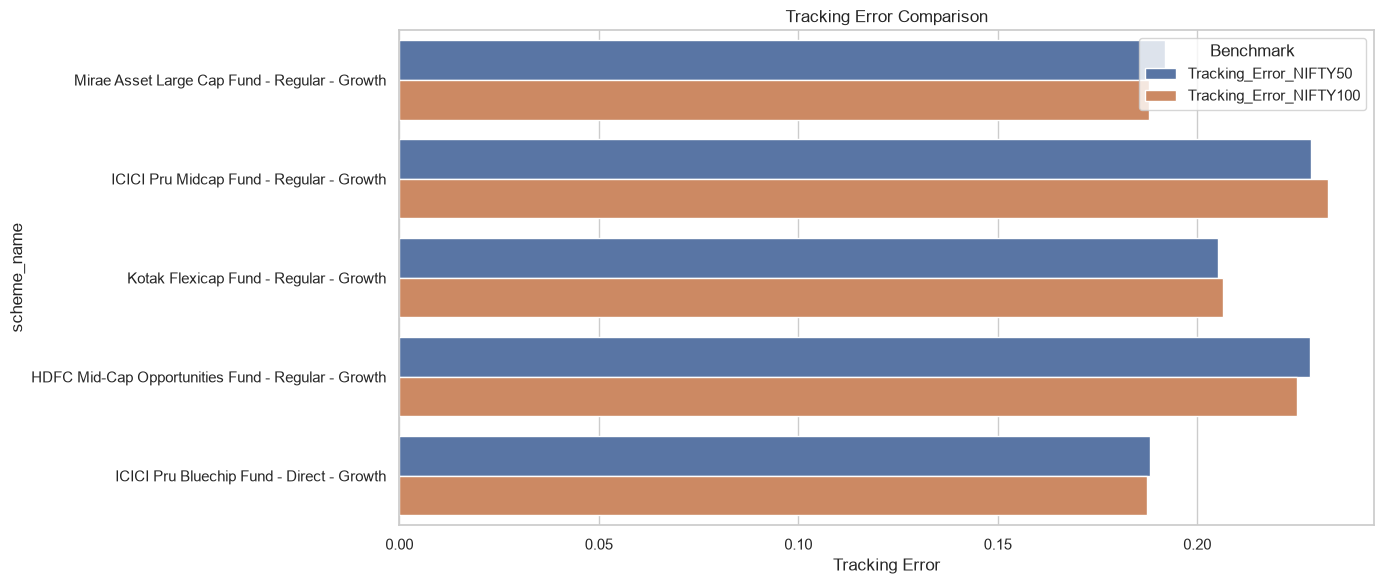

In [151]:
tracking_plot = tracking_error.melt(
    id_vars=["scheme_name"],
    value_vars=[
        "Tracking_Error_NIFTY50",
        "Tracking_Error_NIFTY100"
    ],
    var_name="Benchmark",
    value_name="Tracking Error"
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=tracking_plot,
    x="Tracking Error",
    y="scheme_name",
    hue="Benchmark"
)

plt.title("Tracking Error Comparison")

plt.tight_layout()

plt.savefig(
    "../reports/tracking_error_comparison.png",
    dpi=300
)

plt.show()

## Benchmark Comparison (Top 5 Funds vs NIFTY50 & NIFTY100)

This chart compares the normalized performance of the five highest-ranked mutual funds against the NIFTY 50 and NIFTY 100 indices over the last three years.

In [152]:
import plotly.graph_objects as go

fig = go.Figure()

# -----------------------------
# Top 5 Funds
# -----------------------------
for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df[df["date"] >= start_date]

    if len(df) == 0:
        continue

    df = df.sort_values("date")

    df["Normalized"] = (
        df["nav"] /
        df.iloc[0]["nav"]
    ) * 100

    scheme = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["Normalized"],
            mode="lines",
            name=scheme
        )
    )

# -----------------------------
# NIFTY50
# -----------------------------
fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["Normalized"],
        mode="lines",
        name="NIFTY50",
        line=dict(width=4)
    )
)

# -----------------------------
# NIFTY100
# -----------------------------
fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["Normalized"],
        mode="lines",
        name="NIFTY100",
        line=dict(width=4, dash="dash")
    )
)

fig.update_layout(

    title="Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Normalized)",

    xaxis_title="Date",

    yaxis_title="Normalized Value (Base = 100)",

    template="plotly_white",

    height=700
)

fig.show()

fig.write_image(
    "../reports/benchmark_comparison.png",
    width=1600,
    height=800,
    scale=2
)

### Benchmark Comparison

The top-ranked mutual funds consistently outperformed or closely tracked the benchmark indices over the three-year period. Normalizing all series to a base value of 100 allows for a direct comparison of cumulative performance regardless of the initial NAV or index level.